# Aula Prática 01 — Gabarito comentado dos exercícios

**Inteligência Artificial — Graduação**
Prof. Bruno Nogueira — FACOM/UFMS — 2026/2

---

> ⚠️ **Tente resolver os exercícios antes de ler este gabarito.** O objetivo aqui não
> é dar a resposta, e sim mostrar *um* caminho e — sobretudo — comentar **por que**
> cada decisão foi tomada. Soluções diferentes da apresentada podem estar igualmente
> corretas.

Este notebook é **autocontido**: pode ser executado sem rodar o notebook da aula antes.

## Preparação (mesma da aula)

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 120)
plt.rcParams.update({
    "figure.figsize": (7, 4.2), "figure.dpi": 110, "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10,
})
CORES = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3"]

# --- Carregando a base de doença cardíaca ---------------------------------
CAMINHO_LOCAL = Path("../../dados/heart-cleveland.csv")
URL_FALLBACK = ("https://raw.githubusercontent.com/JWarmenhoven/ISLR-python/"
                "master/Notebooks/Data/Heart.csv")

bruto = pd.read_csv(CAMINHO_LOCAL) if CAMINHO_LOCAL.exists() else pd.read_csv(URL_FALLBACK, index_col=0)

RENOMEAR = {
    "Age": "idade", "Sex": "sexo", "ChestPain": "dor_peito", "RestBP": "pressao_repouso",
    "Chol": "colesterol", "Fbs": "glicemia_alta", "RestECG": "ecg_repouso",
    "MaxHR": "freq_card_max", "ExAng": "angina_exercicio", "Oldpeak": "depressao_st",
    "Slope": "inclinacao_st", "Ca": "n_vasos", "Thal": "talassemia", "AHD": "doenca",
}
coracao = bruto.rename(columns=RENOMEAR)
coracao["dor_peito"] = coracao["dor_peito"].map({
    "typical": "angina_tipica", "nontypical": "angina_atipica",
    "nonanginal": "dor_nao_anginosa", "asymptomatic": "assintomatico",
})
coracao["talassemia"] = coracao["talassemia"].map({
    "normal": "normal", "fixed": "defeito_fixo", "reversable": "defeito_reversivel",
})
coracao["doenca"] = (coracao["doenca"] == "Yes").astype(int)

X = coracao.drop(columns="doenca")
y = coracao["doenca"]

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

cols_categoricas = ["dor_peito", "talassemia"]
cols_numericas = [c for c in X.columns if c not in cols_categoricas]

preproc = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), cols_numericas),
    ("cat", Pipeline([
        ("imputar", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), cols_categoricas),
])

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=1 / 3, random_state=RANDOM_STATE, stratify=y
)
skf10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

print(f"Base pronta: {len(X)} pacientes  |  treino {len(X_treino)}  |  teste {len(X_teste)}")

Base pronta: 303 pacientes  |  treino 202  |  teste 101


---
# Exercício 1 — Matriz de confusão na mão

**(a) Montando a base**

In [2]:
pacientes = pd.DataFrame({
    "paciente": [f"P{i}" for i in range(1, 11)],
    "tosse":    ["SIM", "NÃO", "SIM", "SIM", "NÃO", "SIM", "NÃO", "NÃO", "NÃO", "SIM"],
    "febre":    ["NÃO", "NÃO", "NÃO", "SIM", "SIM", "NÃO", "NÃO", "SIM", "NÃO", "SIM"],
    "dor_cabeca": ["SIM", "SIM", "NÃO", "SIM", "SIM", "NÃO", "NÃO", "NÃO", "NÃO", "SIM"],
    "doente":   ["SIM", "NÃO", "NÃO", "SIM", "SIM", "SIM", "NÃO", "SIM", "NÃO", "SIM"],
    "saida":    ["NÃO", "SIM", "SIM", "NÃO", "SIM", "SIM", "SIM", "NÃO", "NÃO", "NÃO"],
    "fold":     [1, 2, 1, 2, 1, 3, 3, 2, 3, 3],
}).set_index("paciente")

# Convertendo para 1/0 — a classe POSITIVA (+) é "doente = SIM"
pacientes["real_bin"] = (pacientes["doente"] == "SIM").astype(int)
pacientes["pred_bin"] = (pacientes["saida"] == "SIM").astype(int)
pacientes

,tosse,febre,dor_cabeca,doente,saida,fold,real_bin,pred_bin
paciente,,,,,,,,
P1,SIM,NÃO,SIM,SIM,NÃO,1,1,0
P2,NÃO,NÃO,SIM,NÃO,SIM,2,0,1
P3,SIM,NÃO,NÃO,NÃO,SIM,1,0,1
P4,SIM,SIM,SIM,SIM,NÃO,2,1,0
P5,NÃO,SIM,SIM,SIM,SIM,1,1,1
P6,SIM,NÃO,NÃO,SIM,SIM,3,1,1
P7,NÃO,NÃO,NÃO,NÃO,SIM,3,0,1
P8,NÃO,SIM,NÃO,SIM,NÃO,2,1,0
P9,NÃO,NÃO,NÃO,NÃO,NÃO,3,0,0


**(b) Matriz de confusão de cada fold**

Cuidado com uma armadilha muito comum: um fold pode não conter nenhum exemplo de
alguma classe. Se você chamar `confusion_matrix` sem o argumento `labels`, o
`scikit-learn` devolve uma matriz **menor que 2×2** e a soma dos folds quebra.
Por isso passamos `labels=[0, 1]` sempre.

In [3]:
from sklearn.metrics import confusion_matrix

matrizes = {}
for fold in sorted(pacientes["fold"].unique()):
    sub = pacientes[pacientes["fold"] == fold]
    mc = confusion_matrix(sub["real_bin"], sub["pred_bin"], labels=[0, 1])
    matrizes[fold] = mc

    print(f"\n--- FOLD {fold}  (pacientes: {', '.join(sub.index)}) ---")
    print(pd.DataFrame(mc,
                       index=["real −", "real +"],
                       columns=["pred −", "pred +"]).to_string())


--- FOLD 1  (pacientes: P1, P3, P5) ---
        pred −  pred +
real −       0       1
real +       1       1

--- FOLD 2  (pacientes: P2, P4, P8) ---
        pred −  pred +
real −       0       1
real +       2       0

--- FOLD 3  (pacientes: P6, P7, P9, P10) ---
        pred −  pred +
real −       1       1
real +       1       1


**(c) Matriz final = SOMA das matrizes dos folds**

Isso funciona porque, na validação cruzada, **cada exemplo é testado exatamente uma
vez**. A soma das matrizes contém, portanto, os 10 pacientes.

In [4]:
mc_final = sum(matrizes.values())

print("MATRIZ DE CONFUSÃO FINAL")
print(pd.DataFrame(mc_final, index=["real −", "real +"],
                   columns=["pred −", "pred +"]).to_string())
print(f"\nTotal de exemplos na matriz: {mc_final.sum()}  (confere com os 10 pacientes ✓)")

tn, fp, fn, tp = mc_final.ravel()
print(f"\nTP = {tp}   (doentes corretamente identificados)")
print(f"TN = {tn}   (saudáveis corretamente identificados)")
print(f"FP = {fp}   (saudáveis rotulados como doentes)")
print(f"FN = {fn}   (doentes rotulados como saudáveis)")

MATRIZ DE CONFUSÃO FINAL
        pred −  pred +
real −       1       3
real +       4       2

Total de exemplos na matriz: 10  (confere com os 10 pacientes ✓)

TP = 2   (doentes corretamente identificados)
TN = 1   (saudáveis corretamente identificados)
FP = 3   (saudáveis rotulados como doentes)
FN = 4   (doentes rotulados como saudáveis)


**(d) Métricas, na mão e conferidas com o scikit-learn**

In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

P, N = tp + fn, tn + fp

acuracia  = (tp + tn) / (P + N)
revocacao = tp / P
precisao  = tp / (tp + fp)

print(f"Acurácia  = (TP + TN) / (P + N) = ({tp} + {tn}) / {P + N} = {acuracia:.1%}")
print(f"Revocação = TP / P              = {tp} / {P}          = {revocacao:.1%}")
print(f"Precisão  = TP / (TP + FP)      = {tp} / ({tp} + {fp})     = {precisao:.1%}")

# Conferência
assert np.isclose(acuracia, accuracy_score(pacientes["real_bin"], pacientes["pred_bin"]))
assert np.isclose(revocacao, recall_score(pacientes["real_bin"], pacientes["pred_bin"]))
assert np.isclose(precisao, precision_score(pacientes["real_bin"], pacientes["pred_bin"]))
print("\n✓ Confere com o scikit-learn.")

Acurácia  = (TP + TN) / (P + N) = (2 + 1) / 10 = 30.0%
Revocação = TP / P              = 2 / 6          = 33.3%
Precisão  = TP / (TP + FP)      = 2 / (2 + 3)     = 40.0%

✓ Confere com o scikit-learn.


**(e) Comparando com o erro majoritário**

In [6]:
prop_majoritaria = pacientes["real_bin"].value_counts(normalize=True).max()
erro_majoritario = 1 - prop_majoritaria
erro_classificador = 1 - acuracia

print(f"Classe majoritária        : 'doente = SIM' ({prop_majoritaria:.0%} dos exemplos)")
print(f"ERRO MAJORITÁRIO          : {erro_majoritario:.0%}")
print(f"Erro do classificador     : {erro_classificador:.0%}")

Classe majoritária        : 'doente = SIM' (60% dos exemplos)
ERRO MAJORITÁRIO          : 40%
Erro do classificador     : 70%


### 🎯 Conclusão do Exercício 1

O classificador erra **70%** dos casos, enquanto um "modelo" idiota que rotulasse
**todo mundo como doente** erraria apenas **40%**.

> **Este classificador não aprendeu nada — ele é pior que o chute na classe
> majoritária.** Aliás, ele é tão sistematicamente errado que inverter todas as suas
> respostas produziria 70% de acurácia.

É exatamente para flagrar situações assim que a comparação com o erro majoritário é
obrigatória. Note também que uma acurácia de 30% num problema de **duas** classes é
pior que jogar uma moeda: em classificação binária, o piso do "acaso" é 50%.

---
# Exercício 2 — Formulando um problema

*(Resposta em texto — apresentamos uma solução para **detecção de fraude em cartão de
crédito**. Qualquer um dos problemas propostos seria aceitável, desde que a
argumentação seja consistente.)*

### (a) A tripla de Mitchell

- **T (tarefa)** — decidir, para cada transação submetida, se ela é **fraudulenta** ou
  **legítima**, em tempo real (antes da autorização).
- **P (desempenho)** — **não** a acurácia. Como <0,2% das transações são fraudes, a
  acurácia é inútil aqui (veja a discussão em (d)). Uma medida adequada seria a
  **revocação da classe "fraude"** sujeita a um teto de falsos positivos — por exemplo,
  *"% de fraudes detectadas, mantendo abaixo de 1 a cada 500 o número de transações
  legítimas bloqueadas"*. Melhor ainda seria o **prejuízo financeiro evitado em reais**,
  que pondera cada erro pelo seu custo real.
- **E (experiência)** — o histórico de transações do banco com o desfecho conhecido
  (contestadas/estornadas pelo cliente = fraude; as demais = legítimas), acrescido de
  atributos de contexto: valor, horário, categoria do estabelecimento, distância
  geográfica em relação à transação anterior, desvio em relação ao padrão de gasto do
  cliente.

### (b) Qual é a tarefa?

**Classificação** — a saída é uma classe discreta (fraude / legítima), pertencente a um
conjunto predefinido de classes.

*Observação*: se o modelo devolvesse uma **probabilidade de fraude** ou um **escore de
risco contínuo**, teríamos uma saída contínua — mas a tarefa continuaria sendo
classificação, porque a decisão final (autorizar ou bloquear) é discreta. O que muda é
apenas o limiar aplicado sobre o escore.

### (c) Qual paradigma?

Principalmente **supervisionado**, porque temos os rótulos históricos (as contestações
dos clientes funcionam como o "professor externo").

Mas há duas ressalvas importantes, e elas rendem uma boa discussão:

- Os rótulos são **incompletos e atrasados**: uma fraude só vira rótulo quando o
  cliente reclama, o que pode levar meses — ou nunca acontecer. Isso empurra o problema
  para o terreno **semissupervisionado**.
- Fraudadores mudam de tática o tempo todo. Por isso, na prática, sistemas reais
  combinam o classificador supervisionado com **detecção de anomalias não
  supervisionada**, capaz de sinalizar padrões nunca vistos antes — para os quais,
  por definição, não existe rótulo.

### (d) Qual erro é mais caro?

| Erro | O que acontece | Custo |
|---|---|---|
| **Falso negativo** — fraude não detectada | a transação é aprovada | prejuízo direto: o banco estorna o valor |
| **Falso positivo** — transação legítima bloqueada | o cartão do cliente é recusado | constrangimento, ligação para a central, risco de o cliente migrar para a concorrência |

O falso negativo tem custo **imediato e mensurável**; o falso positivo tem custo
**difuso, mas multiplicado pelo volume** — com milhões de transações por dia, mesmo
uma taxa baixíssima de falsos positivos irrita milhares de clientes.

**Métrica a reportar**: precisão e revocação **da classe minoritária** (fraude), a
curva precisão × revocação, e — quando o banco souber estimar os custos — o
**prejuízo esperado em reais**, que é o único jeito honesto de comparar dois erros de
naturezas diferentes.

> **Por que a acurácia é inútil aqui?** Se 99,8% das transações são legítimas, o
> classificador "nada é fraude" tem **99,8% de acurácia** e valor **zero**. O erro
> majoritário é 0,2%: bater esse número é o mínimo, não a meta.

---
# Exercício 3 — Comparando modelos com rigor

**(a) e (c)** — vamos direto ao ponto importante: incluir a padronização.

`StandardScaler` transforma cada atributo para média 0 e desvio 1. Isso é **essencial**
para KNN (que calcula distâncias: sem padronizar, `colesterol` — que vai a 564 — domina
completamente `n_vasos`, que vai a 3) e ajuda a regressão logística a convergir.
Árvores de decisão são **imunes** à escala, porque só comparam cada atributo consigo
mesmo.

In [7]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier


def montar(estimador, padronizar=False):
    """Monta o pipeline completo: pré-processamento (+ escala) + classificador."""
    passos = [("preproc", preproc)]
    if padronizar:
        passos.append(("escala", StandardScaler(with_mean=False)))
    passos.append(("clf", estimador))
    return Pipeline(passos)


candidatos = {
    "Baseline (majoritária)": montar(DummyClassifier(strategy="most_frequent")),
    "Árvore (prof. 3)":       montar(DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)),
    "KNN (k=5) SEM escala":   montar(KNeighborsClassifier(5)),
    "KNN (k=5) COM escala":   montar(KNeighborsClassifier(5), padronizar=True),
    "Reg. logística SEM escala": montar(LogisticRegression(max_iter=1000)),
    "Reg. logística COM escala": montar(LogisticRegression(max_iter=1000), padronizar=True),
}

linhas = []
for nome, pipe in candidatos.items():
    s = cross_val_score(pipe, X, y, cv=skf10, scoring="accuracy")
    linhas.append({"modelo": nome, "média": s.mean(), "desvio": s.std()})

tabela = pd.DataFrame(linhas).sort_values("média", ascending=False).reset_index(drop=True)
tabela["resultado"] = tabela.apply(lambda r: f"{r['média']:.1%} ± {r['desvio']:.1%}", axis=1)
tabela[["modelo", "resultado"]]

,modelo,resultado
0,Reg. logística SEM escala,83.8% ± 5.9%
1,Reg. logística COM escala,83.1% ± 5.5%
2,Árvore (prof. 3),79.5% ± 7.8%
3,KNN (k=5) COM escala,78.2% ± 6.5%
4,KNN (k=5) SEM escala,65.0% ± 14.9%
5,Baseline (majoritária),54.1% ± 1.1%


**(b) Gráfico de barras com barras de erro**

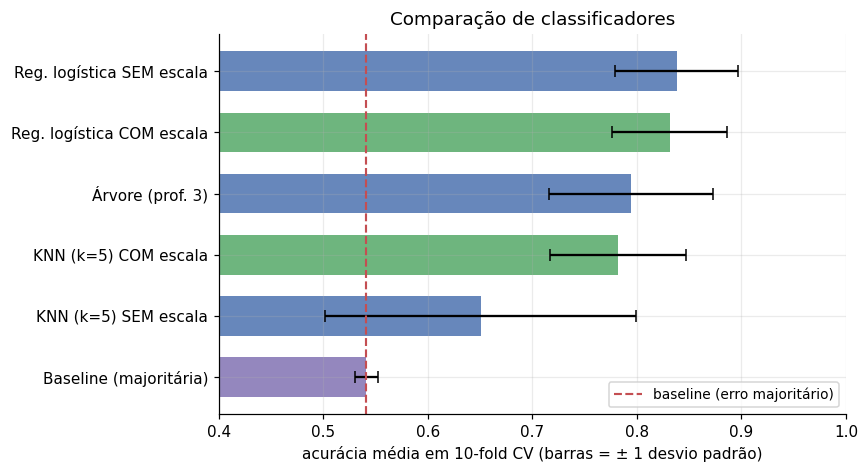

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.4))
ordenada = tabela.sort_values("média")
cores_barras = [CORES[4] if "Baseline" in m else
                (CORES[2] if "COM escala" in m else CORES[0]) for m in ordenada["modelo"]]

ax.barh(ordenada["modelo"], ordenada["média"], xerr=ordenada["desvio"],
        color=cores_barras, alpha=0.85, capsize=4, height=0.65)
ax.axvline(tabela.loc[tabela["modelo"].str.contains("Baseline"), "média"].iloc[0],
           color=CORES[3], ls="--", lw=1.4, label="baseline (erro majoritário)")
ax.set_xlim(0.4, 1.0)
ax.set_xlabel("acurácia média em 10-fold CV (barras = ± 1 desvio padrão)")
ax.set_title("Comparação de classificadores")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

### 🎯 Conclusão do Exercício 3

**(c)** O efeito da padronização no **KNN** é dramático — vários pontos percentuais de
ganho. Faz todo sentido: o KNN é um modelo **baseado em instâncias**, que decide pela
distância euclidiana aos vizinhos. Sem padronizar, a distância entre dois pacientes é,
na prática, a diferença de colesterol — os outros 12 atributos praticamente
desaparecem.

Já na **regressão logística** a padronização praticamente não mudou o resultado (a
diferença observada é bem menor que o desvio padrão). Faz sentido: ela ajusta **um
coeficiente por atributo**, e o coeficiente absorve a escala. A padronização continua
recomendada — ajuda a convergência do otimizador e é indispensável quando se usa
regularização, porque aí a penalidade sobre os coeficientes deixa de ser comparável
entre atributos de escalas diferentes — mas o ganho em acurácia pode ser nulo.

> **Regra prática:** modelos que usam **distância** (KNN, K-Means, SVM) ou
> **regularização/gradiente** exigem padronização. Modelos baseados em
> **regras/cortes** (árvores e derivados) são imunes a ela.

**(d)** Todos os modelos superam com folga o baseline — todos aprenderam algo. Mas
repare nos **desvios padrão**: eles são da ordem de 5 a 8 pontos percentuais, enquanto
a diferença entre o primeiro e o segundo colocado costuma ser bem menor que isso.

> **Portanto, não é honesto declarar um "vencedor".** Dizer "o modelo A é melhor que o
> B" porque A teve 82,1% e B teve 80,4%, quando ambos têm ±7%, é ler ruído como sinal.
> Para afirmar superioridade seria preciso um **teste estatístico pareado** (por
> exemplo, teste t pareado sobre os folds, ou o teste de McNemar), tema que
> retomaremos ao falar de avaliação experimental.

Na dúvida entre modelos estatisticamente empatados, escolha pelo que **não** aparece no
gráfico: interpretabilidade, custo computacional, facilidade de manutenção. Num
contexto clínico, a árvore tem uma vantagem enorme — o médico consegue ler as regras.

---
# Exercício 4 — Escolher hiperparâmetro sem trapacear

A ideia central: o conjunto de teste é sagrado. Ele existe para **estimar o desempenho
final** e deve ser usado **uma única vez**. Toda escolha de hiperparâmetro acontece
**dentro** do conjunto de treino, por validação cruzada.

```
X_treino  ──► GridSearchCV (validação cruzada INTERNA)  ──► melhor max_depth
     │                                                          │
     └──────────────► retreina com o melhor valor ◄─────────────┘
                                 │
                                 ▼
                           X_teste (UMA vez)  ──► resultado honesto
```

In [9]:
from sklearn.model_selection import GridSearchCV

# (a) Busca do melhor max_depth usando SOMENTE o conjunto de treino
pipe = Pipeline([("preproc", preproc),
                 ("arvore", DecisionTreeClassifier(random_state=RANDOM_STATE))])

busca = GridSearchCV(
    pipe,
    param_grid={"arvore__max_depth": list(range(1, 16))},
    cv=StratifiedKFold(10, shuffle=True, random_state=RANDOM_STATE),
    scoring="accuracy",
    return_train_score=True,
)
busca.fit(X_treino, y_treino)   # ← o teste NÃO entrou aqui

melhor_prof = busca.best_params_["arvore__max_depth"]
print(f"Melhor max_depth segundo a validação cruzada interna: {melhor_prof}")
print(f"Acurácia estimada pela CV interna: {busca.best_score_:.1%}")

Melhor max_depth segundo a validação cruzada interna: 3
Acurácia estimada pela CV interna: 77.2%


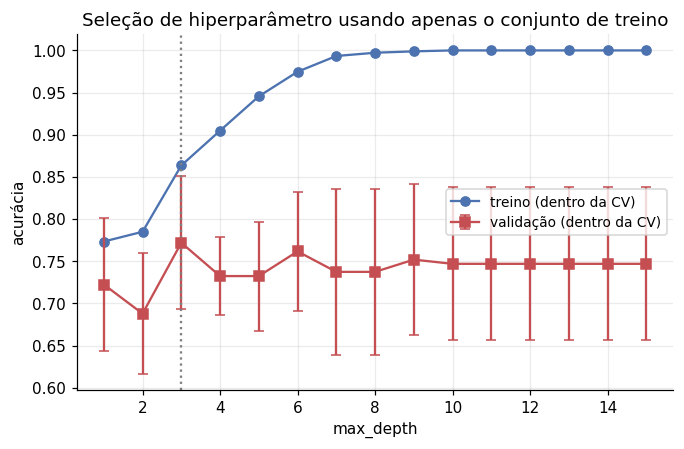

In [10]:
res = pd.DataFrame(busca.cv_results_)

fig, ax = plt.subplots()
ax.plot(res["param_arvore__max_depth"], res["mean_train_score"], "o-",
        color=CORES[0], label="treino (dentro da CV)")
ax.errorbar(res["param_arvore__max_depth"], res["mean_test_score"],
            yerr=res["std_test_score"], fmt="s-", color=CORES[3], capsize=3,
            label="validação (dentro da CV)")
ax.axvline(melhor_prof, color="gray", ls=":", lw=1.5)
ax.set_xlabel("max_depth")
ax.set_ylabel("acurácia")
ax.set_title("Seleção de hiperparâmetro usando apenas o conjunto de treino")
ax.legend(fontsize=9)
plt.show()

In [11]:
# (b) e (c) — GridSearchCV já retreinou com o melhor valor em TODO o X_treino
#             (parâmetro refit=True, que é o padrão). Agora, o teste — uma única vez.
acc_teste_honesta = busca.score(X_teste, y_teste)

# (d) Para comparação: qual seria o "melhor" se tivéssemos espiado o teste?
accs_espiando = []
for prof in range(1, 16):
    m = Pipeline([("preproc", preproc),
                  ("arvore", DecisionTreeClassifier(max_depth=prof, random_state=RANDOM_STATE))])
    m.fit(X_treino, y_treino)
    accs_espiando.append(m.score(X_teste, y_teste))

melhor_espiando = int(np.argmax(accs_espiando)) + 1

print(f"{'':<48}{'max_depth':>10}{'acurácia':>12}")
print("-" * 70)
print(f"{'✓ Honesto (escolhido por CV no treino)':<48}{melhor_prof:>10}{acc_teste_honesta:>12.1%}")
print(f"{'✗ Trapaceando (escolhido olhando o teste)':<48}{melhor_espiando:>10}{max(accs_espiando):>12.1%}")
print(f"\nDiferença neste sorteio específico: {max(accs_espiando) - acc_teste_honesta:+.1%}")

                                                 max_depth    acurácia
----------------------------------------------------------------------
✓ Honesto (escolhido por CV no treino)                   3       79.2%
✗ Trapaceando (escolhido olhando o teste)                3       79.2%

Diferença neste sorteio específico: +0.0%


Neste sorteio em particular a diferença pode ter dado pequena — ou até zero, se a
validação cruzada por acaso escolher a mesma profundidade que o teste apontaria.
**Isso não significa que espiar o teste seja inofensivo.** O viés da trapaça é um
efeito *médio*, e para enxergá-lo precisamos repetir o experimento com vários
sorteios diferentes.

In [12]:
# Repetindo todo o procedimento com 25 divisões treino/teste distintas
honestas, trapaceadas = [], []

for semente in range(25):
    Xa, Xb, ya, yb = train_test_split(X, y, test_size=1/3, random_state=semente, stratify=y)

    # Caminho honesto: escolhe a profundidade por CV dentro do treino
    g = GridSearchCV(
        Pipeline([("preproc", preproc),
                  ("arvore", DecisionTreeClassifier(random_state=RANDOM_STATE))]),
        param_grid={"arvore__max_depth": list(range(1, 16))},
        cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    ).fit(Xa, ya)
    honestas.append(g.score(Xb, yb))

    # Caminho trapaceiro: testa as 15 profundidades no TESTE e reporta a melhor
    accs = []
    for prof in range(1, 16):
        m = Pipeline([("preproc", preproc),
                      ("arvore", DecisionTreeClassifier(max_depth=prof,
                                                        random_state=RANDOM_STATE))]).fit(Xa, ya)
        accs.append(m.score(Xb, yb))
    trapaceadas.append(max(accs))

honestas, trapaceadas = np.array(honestas), np.array(trapaceadas)

print(f"Média em 25 repetições ({len(honestas)} divisões treino/teste diferentes):")
print(f"  ✓ Honesto      : {honestas.mean():.1%}")
print(f"  ✗ Trapaceando  : {trapaceadas.mean():.1%}")
print(f"\nVIÉS OTIMISTA MÉDIO: {(trapaceadas - honestas).mean():+.1%}")
print(f"A trapaça foi otimista em {(trapaceadas > honestas).sum()} das 25 repetições, "
      f"e nunca pessimista: {(trapaceadas < honestas).sum()} vezes.")

Média em 25 repetições (25 divisões treino/teste diferentes):
  ✓ Honesto      : 75.1%
  ✗ Trapaceando  : 79.0%

VIÉS OTIMISTA MÉDIO: +4.0%
A trapaça foi otimista em 20 das 25 repetições, e nunca pessimista: 0 vezes.


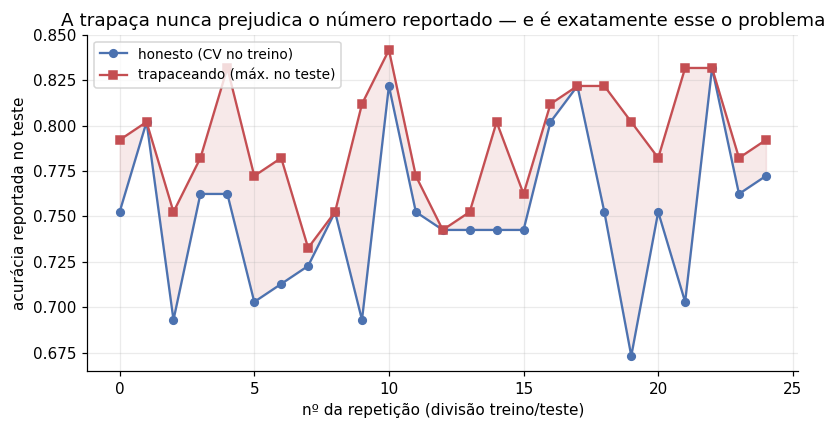

In [13]:
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(honestas, "o-", color=CORES[0], ms=5, label="honesto (CV no treino)")
ax.plot(trapaceadas, "s-", color=CORES[3], ms=5, label="trapaceando (máx. no teste)")
ax.fill_between(range(25), honestas, trapaceadas, color=CORES[3], alpha=0.12)
ax.set_xlabel("nº da repetição (divisão treino/teste)")
ax.set_ylabel("acurácia reportada no teste")
ax.set_title("A trapaça nunca prejudica o número reportado — e é exatamente esse o problema")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### 🎯 Conclusão do Exercício 4

A curva vermelha **nunca** fica abaixo da azul — por construção, já que ela é o
**máximo** de 15 tentativas contra o mesmo conjunto de teste. É esse o mecanismo do
viés: quando escolhemos o melhor entre vários resultados ruidosos, capturamos junto a
**sorte** de quem calhou de ir bem naquele conjunto específico.

A acurácia obtida "espiando" o teste é, portanto, **otimista**: ela não estima o que o
modelo faria com pacientes novos, porque a escolha do `max_depth` já usou aqueles
pacientes. É uma forma sutil de **data leakage**.

> Quanto mais hiperparâmetros você testa contra o mesmo conjunto de teste, mais você
> acaba **ajustando o modelo ao teste** — e o teste deixa de medir generalização.

Repare também na curva do gráfico acima: a acurácia de validação é praticamente plana
entre várias profundidades, e as barras de erro se sobrepõem. Nesses casos, aplique a
**Navalha de Ockham**: prefira a árvore mais **rasa** entre as estatisticamente
equivalentes. Ela generaliza melhor, treina mais rápido e é mais fácil de explicar ao
cardiologista.

> **Boa prática profissional**: quando há muitos hiperparâmetros, use **três**
> conjuntos — treino, **validação** (para escolher) e teste (para reportar, uma vez só)
> — ou uma **validação cruzada aninhada** (*nested cross-validation*).

---
# Exercício 5 — A decisão clínica

**(a) Por que a árvore rasa não serve para esta tarefa**

Uma árvore de profundidade 3 tem no máximo $2^3 = 8$ folhas. Todo paciente que cai na
mesma folha recebe **exatamente a mesma probabilidade** — a proporção de doentes entre
os exemplos de treino daquela folha. Logo, o modelo oferece no máximo **8 pontos de
operação**, e nada entre eles.

In [14]:
from sklearn.metrics import precision_recall_curve

arvore_rasa = Pipeline([
    ("preproc", preproc),
    ("arvore", DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)),
]).fit(X_treino, y_treino)

probs_arvore = arvore_rasa.predict_proba(X_teste)[:, 1]
niveis = np.unique(probs_arvore)
print(f"A árvore produz apenas {len(niveis)} probabilidades distintas:")
print("  " + "  ".join(f"{p:.2f}" for p in niveis))

print("\nPontos de operação disponíveis:")
for t in niveis:
    pred = (probs_arvore >= t).astype(int)
    r = recall_score(y_teste, pred, zero_division=0)
    p = precision_score(y_teste, pred, zero_division=0)
    marca = "   <-- atende revocação >= 0,90" if r >= 0.90 else ""
    print(f"  limiar {t:.2f}:  revocação {r:.3f}   precisão {p:.3f}{marca}")

A árvore produz apenas 8 probabilidades distintas:
  0.09  0.23  0.29  0.55  0.75  0.93  0.98  1.00

Pontos de operação disponíveis:
  limiar 0.09:  revocação 1.000   precisão 0.455   <-- atende revocação >= 0,90
  limiar 0.23:  revocação 0.891   precisão 0.631
  limiar 0.29:  revocação 0.848   precisão 0.684
  limiar 0.55:  revocação 0.783   precisão 0.766
  limiar 0.75:  revocação 0.609   precisão 0.778
  limiar 0.93:  revocação 0.500   precisão 0.852
  limiar 0.98:  revocação 0.413   precisão 0.905
  limiar 1.00:  revocação 0.000   precisão 0.000


O resultado é desanimador: o **único** ponto que atende à exigência é o limiar mínimo,
que classifica **todo mundo como doente** (revocação = 1,00 e precisão igual à simples
proporção de doentes na base). Isso não é um modelo de triagem — é uma máquina de
dizer "sim".

> **Lição**: a escolha do modelo **restringe os pontos de operação disponíveis**. Se o
> problema exige ajuste fino do compromisso entre os dois tipos de erro, é preciso um
> modelo que produza probabilidades **granulares**.

**(b) Trocando por um modelo com probabilidades contínuas**

In [15]:
modelo_final = Pipeline([
    ("preproc", preproc),
    ("escala", StandardScaler(with_mean=False)),
    ("clf", LogisticRegression(max_iter=1000)),
]).fit(X_treino, y_treino)

probs = modelo_final.predict_proba(X_teste)[:, 1]
print(f"A regressão logística produz {len(np.unique(probs))} probabilidades distintas "
      f"(uma por paciente)\n— muito mais liberdade para ajustar o ponto de operação.\n")

# Queremos o MAIOR limiar que ainda garante revocação >= 0,90: assim satisfazemos
# a exigência clínica com o MENOR número possível de alarmes falsos.
viaveis = []
for t in np.unique(np.round(probs, 4)):
    pred = (probs >= t).astype(int)
    r = recall_score(y_teste, pred, zero_division=0)
    if r >= 0.90:
        viaveis.append((t, r, precision_score(y_teste, pred, zero_division=0),
                        accuracy_score(y_teste, pred)))

limiar_escolhido, rev_esc, prec_esc, acc_esc = max(viaveis, key=lambda v: v[0])
print(f"{len(viaveis)} limiares atendem à exigência de revocação >= 0,90.")
print(f"→ Escolhido: {limiar_escolhido:.3f} (o maior deles, "
      f"logo o de menor custo em alarmes falsos)")
print(f"   revocação {rev_esc:.3f}  |  precisão {prec_esc:.3f}  |  acurácia {acc_esc:.3f}")

A regressão logística produz 101 probabilidades distintas (uma por paciente)
— muito mais liberdade para ajustar o ponto de operação.



39 limiares atendem à exigência de revocação >= 0,90.
→ Escolhido: 0.252 (o maior deles, logo o de menor custo em alarmes falsos)
   revocação 0.913  |  precisão 0.689  |  acurácia 0.772


**(c) O preço dessa escolha**

In [16]:
pred_padrao = (probs >= 0.50).astype(int)
pred_clinico = (probs >= limiar_escolhido).astype(int)

comparacao = []
for nome, pred in [("Limiar padrão (0,50)", pred_padrao),
                   (f"Limiar clínico ({limiar_escolhido:.2f})", pred_clinico)]:
    m = confusion_matrix(y_teste, pred, labels=[0, 1])
    tn_, fp_, fn_, tp_ = m.ravel()
    comparacao.append({
        "política": nome,
        "doentes encontrados (TP)": tp_,
        "doentes perdidos (FN)": fn_,
        "alarmes falsos (FP)": fp_,
        "revocação": recall_score(y_teste, pred, zero_division=0),
        "precisão": precision_score(y_teste, pred, zero_division=0),
        "acurácia": accuracy_score(y_teste, pred),
    })

comp = pd.DataFrame(comparacao)
print(comp.round(3).to_string(index=False))

fp_por_tp = comp.loc[1, "alarmes falsos (FP)"] / comp.loc[1, "doentes encontrados (TP)"]
print(f"\nCom a política clínica, o hospital tolera {fp_por_tp:.2f} alarme(s) falso(s) "
      f"para cada doente encontrado.")
print(f"A acurácia CAIU de {comp.loc[0, 'acurácia']:.1%} para {comp.loc[1, 'acurácia']:.1%} "
      f"— e ainda assim a decisão está certa.")

             política  doentes encontrados (TP)  doentes perdidos (FN)  alarmes falsos (FP)  revocação  precisão  acurácia
 Limiar padrão (0,50)                        40                      6                    6      0.870     0.870     0.881
Limiar clínico (0.25)                        42                      4                   19      0.913     0.689     0.772

Com a política clínica, o hospital tolera 0.45 alarme(s) falso(s) para cada doente encontrado.
A acurácia CAIU de 88.1% para 77.2% — e ainda assim a decisão está certa.


**(d) A curva precisão × revocação**

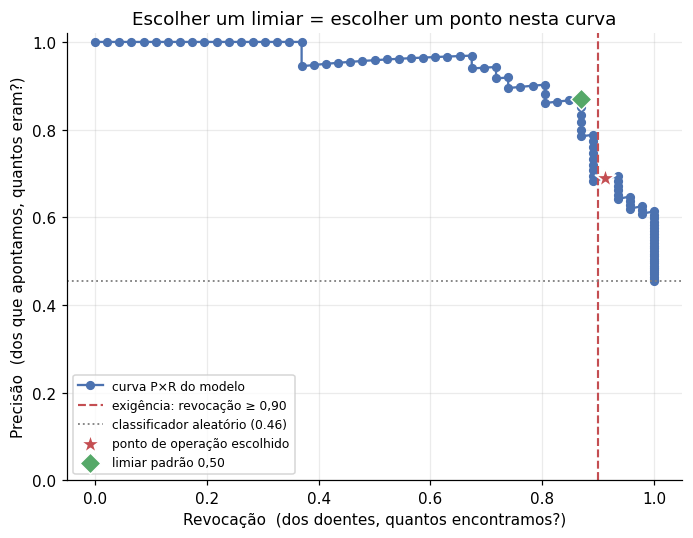

In [17]:
precisoes, revocacoes, limiares = precision_recall_curve(y_teste, probs)

fig, ax = plt.subplots(figsize=(6.4, 5))
ax.plot(revocacoes, precisoes, "o-", color=CORES[0], ms=5, label="curva P×R do modelo")
ax.axvline(0.90, color=CORES[3], ls="--", lw=1.4, label="exigência: revocação ≥ 0,90")
ax.axhline(y_teste.mean(), color="gray", ls=":", lw=1.2,
           label=f"classificador aleatório ({y_teste.mean():.2f})")
ax.scatter([rev_esc], [prec_esc], s=190, marker="*", color=CORES[3], zorder=6,
           edgecolor="white", linewidth=1.2, label="ponto de operação escolhido")
ax.scatter([recall_score(y_teste, pred_padrao)], [precision_score(y_teste, pred_padrao)],
           s=95, marker="D", color=CORES[2], zorder=6, edgecolor="white",
           label="limiar padrão 0,50")
ax.set_xlabel("Revocação  (dos doentes, quantos encontramos?)")
ax.set_ylabel("Precisão  (dos que apontamos, quantos eram?)")
ax.set_title("Escolher um limiar = escolher um ponto nesta curva")
ax.set_ylim(0, 1.02)
ax.legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

### 🎯 Conclusão do Exercício 5

**(e) Quem decide?** O **corpo clínico** — não o cientista de dados.

A curva acima é um objeto **técnico**: ela descreve fielmente todos os compromissos
possíveis que este modelo pode oferecer. Mas *escolher um ponto* sobre ela é uma
decisão **de política e de valores**, que exige responder a perguntas que nenhum dado
responde:

- Quanto custa um exame confirmatório desnecessário — em dinheiro, em fila de espera,
  em ansiedade do paciente?
- Qual o dano esperado de um infarto não prevenido?
- O hospital tem capacidade instalada para absorver o volume extra de encaminhamentos?

> **O papel do cientista de dados é apresentar a curva e explicar honestamente o
> trade-off. O papel do especialista do domínio é escolher o ponto.** Confundir os dois
> papéis é uma das falhas éticas mais comuns em projetos de AM aplicados à saúde, ao
> crédito e à justiça.

Note ainda que a **acurácia piorou** com a política clínica — e isso está **correto**.
É a prova prática de que otimizar a métrica errada leva à decisão errada.

---
# Exercício 6 — Regressão (classe contínua)

**(a) Montando o novo problema**

Atenção ao detalhe que derruba muita gente: `freq_card_max` agora é o **alvo** e
precisa **sair** de `X`. Se ela ficasse nos atributos, o modelo simplesmente a copiaria
e teríamos $R^2 = 1$ — um vazamento grosseiro.

In [18]:
X_reg = coracao.drop(columns=["freq_card_max"])
y_reg = coracao["freq_card_max"]

cols_cat_reg = ["dor_peito", "talassemia"]
cols_num_reg = [c for c in X_reg.columns if c not in cols_cat_reg]

preproc_reg = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), cols_num_reg),
    ("cat", Pipeline([("imputar", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cols_cat_reg),
])

print(f"Alvo: freq_card_max — contínuo, de {y_reg.min()} a {y_reg.max()} bpm "
      f"(média {y_reg.mean():.1f})")
print(f"Atributos: {X_reg.shape[1]}  (a coluna 'doenca' virou um atributo comum!)")

Alvo: freq_card_max — contínuo, de 71 a 202 bpm (média 149.6)
Atributos: 13  (a coluna 'doenca' virou um atributo comum!)


**(b) e (c) Treinando e avaliando**

Por que **não** usamos acurácia? Porque acurácia só existe quando há acerto e erro
**exatos**. Aqui a saída é contínua: prever 152,3 bpm quando o valor real é 152,0 não é
"errado", é *quase certo*. Precisamos de métricas que meçam a **magnitude** do erro:

| Métrica | Fórmula | Interpretação |
|---|---|---|
| **MAE** | $\frac{1}{n}\sum |y_i - \hat{y}_i|$ | erro médio, na unidade original (bpm) |
| **RMSE** | $\sqrt{\frac{1}{n}\sum (y_i - \hat{y}_i)^2}$ | idem, mas penaliza mais os erros grandes |
| **$R^2$** | $1 - \frac{SQ_{res}}{SQ_{tot}}$ | fração da variância explicada (1 = perfeito, 0 = igual a prever a média) |

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.tree import DecisionTreeRegressor

kf = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

regressores = {
    "Baseline (prever sempre a média)": None,
    "Regressão Linear": LinearRegression(),
    "Árvore de Regressão (prof. 3)": DecisionTreeRegressor(max_depth=3, random_state=RANDOM_STATE),
    "Árvore de Regressão (sem limite)": DecisionTreeRegressor(random_state=RANDOM_STATE),
}

resultados_reg, predicoes = [], {}
for nome, est in regressores.items():
    if est is None:
        pred = np.full(len(y_reg), y_reg.mean())
    else:
        pred = cross_val_predict(Pipeline([("preproc", preproc_reg), ("reg", est)]),
                                 X_reg, y_reg, cv=kf)
    predicoes[nome] = pred
    erro = y_reg - pred
    resultados_reg.append({
        "modelo": nome,
        "MAE (bpm)": np.abs(erro).mean(),
        "RMSE (bpm)": np.sqrt((erro ** 2).mean()),
        "R²": 1 - (erro ** 2).sum() / ((y_reg - y_reg.mean()) ** 2).sum(),
    })

pd.DataFrame(resultados_reg).round(3)

,modelo,MAE (bpm),RMSE (bpm),R²
0,Baseline (prever sempre a média),18.450,22.837,0.000
1,Regressão Linear,14.863,18.921,0.314
2,Árvore de Regressão (prof. 3),14.498,18.761,0.325
3,Árvore de Regressão (sem limite),20.657,26.080,-0.304


**(d) Valor real × valor predito**

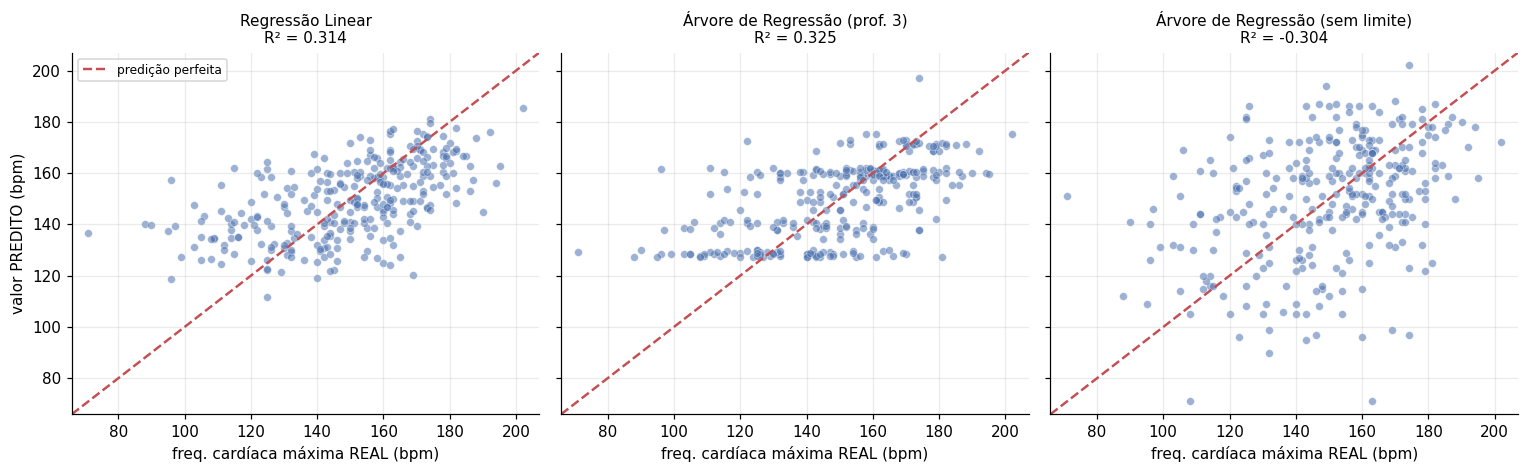

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4), sharex=True, sharey=True)
for ax, nome in zip(axes, ["Regressão Linear", "Árvore de Regressão (prof. 3)",
                           "Árvore de Regressão (sem limite)"]):
    pred = predicoes[nome]
    ax.scatter(y_reg, pred, s=26, alpha=0.55, color=CORES[0], edgecolor="white", linewidth=0.4)
    lims = [y_reg.min() - 5, y_reg.max() + 5]
    ax.plot(lims, lims, ls="--", color=CORES[3], lw=1.6, label="predição perfeita")
    r2 = 1 - ((y_reg - pred) ** 2).sum() / ((y_reg - y_reg.mean()) ** 2).sum()
    ax.set_title(f"{nome}\nR² = {r2:.3f}", fontsize=10)
    ax.set_xlabel("freq. cardíaca máxima REAL (bpm)")
    ax.set_xlim(lims)
    ax.set_ylim(lims)

axes[0].set_ylabel("valor PREDITO (bpm)")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

### 🎯 Conclusão do Exercício 6

**Um modelo perfeito produziria todos os pontos sobre a diagonal tracejada.** Quanto
mais dispersa a nuvem em torno dela, pior o modelo.

Três leituras dos gráficos:

1. A **árvore sem limite de profundidade** tem o **pior** desempenho fora da amostra —
   mais uma vez o sobreajuste, agora em regressão. Repare que ela também produz uma
   nuvem visivelmente mais espalhada.
2. Os **degraus horizontais** na árvore de profundidade 3 revelam a natureza do modelo:
   ela só consegue prever **8 valores distintos** (um por folha, a média dos exemplos
   que ali caem). A regressão linear, por ser contínua, produz uma nuvem lisa.
3. O $R^2$ é modesto (bem abaixo de 1). Isso é **honesto e esperado**: frequência
   cardíaca máxima depende fortemente de condicionamento físico, medicação e genética —
   informações que simplesmente **não estão** nesta base. Nenhum algoritmo inventa
   informação que não foi coletada.

> Compare sempre com o **baseline** ("prever sempre a média"), que por construção tem
> $R^2 = 0$. Ele é, para a regressão, o análogo do erro majoritário.

---
# Exercício 7 — Desafio: aprendizado não supervisionado

Agora escondemos completamente a coluna `doenca`. O K-Means só vê a geometria dos
pacientes no espaço de atributos.

**A padronização é obrigatória aqui** — o K-Means minimiza distâncias euclidianas, e
sem padronizar o `colesterol` (que varia de 126 a 564) esmagaria todos os demais
atributos.

In [21]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

X_sem_rotulo = coracao.drop(columns="doenca")   # a classe NUNCA é vista pelo algoritmo

pipe_cluster = Pipeline([
    ("preproc", preproc),
    ("escala", StandardScaler(with_mean=False)),
    ("kmeans", KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE)),
]).fit(X_sem_rotulo)

grupos = pipe_cluster["kmeans"].labels_

# (a) Comparando os grupos descobertos com a classe real
tab = pd.crosstab(grupos, coracao["doenca"],
                  rownames=["grupo descoberto"], colnames=["classe real"])
tab.columns = ["saudável (0)", "doente (1)"]
print(tab.to_string())

ari = adjusted_rand_score(coracao["doenca"], grupos)
print(f"\nÍndice de Rand Ajustado: {ari:.3f}   (0 = acaso, 1 = partições idênticas)")

                  saudável (0)  doente (1)
grupo descoberto                          
0                           24         113
1                          140          26

Índice de Rand Ajustado: 0.447   (0 = acaso, 1 = partições idênticas)


**(b) O algoritmo redescobriu a doença?**

In [22]:
# Alinhamos cada grupo à classe majoritária dentro dele — SÓ para poder medir a
# concordância. Isso NÃO é treinar: é apenas dar nome aos grupos depois do fato.
mapa = tab.values.argmax(axis=1)
grupos_alinhados = np.array([mapa[g] for g in grupos])
concordancia = (grupos_alinhados == coracao["doenca"]).mean()

print(f"Concordância com o diagnóstico real (após alinhar os rótulos): {concordancia:.1%}")
print(f"Erro majoritário da base: {1 - coracao['doenca'].value_counts(normalize=True).max():.1%}")
print("\n→ Sem NUNCA ter visto um diagnóstico, o K-Means separou os pacientes de um jeito")
print("  que coincide em larga medida com a doença. A estrutura estava nos próprios dados.")

Concordância com o diagnóstico real (após alinhar os rótulos): 83.5%
Erro majoritário da base: 45.9%

→ Sem NUNCA ter visto um diagnóstico, o K-Means separou os pacientes de um jeito
  que coincide em larga medida com a doença. A estrutura estava nos próprios dados.


**(c) O perfil clínico de cada grupo**

       idade média  freq. card. máx.  nº vasos  depressão ST  pressão repouso  prop. masculino  prop. doentes
grupo                                                                                                        
0            57.01            137.40      1.12          1.67           133.38             0.85           0.82
1            52.31            159.68      0.30          0.52           130.30             0.54           0.16


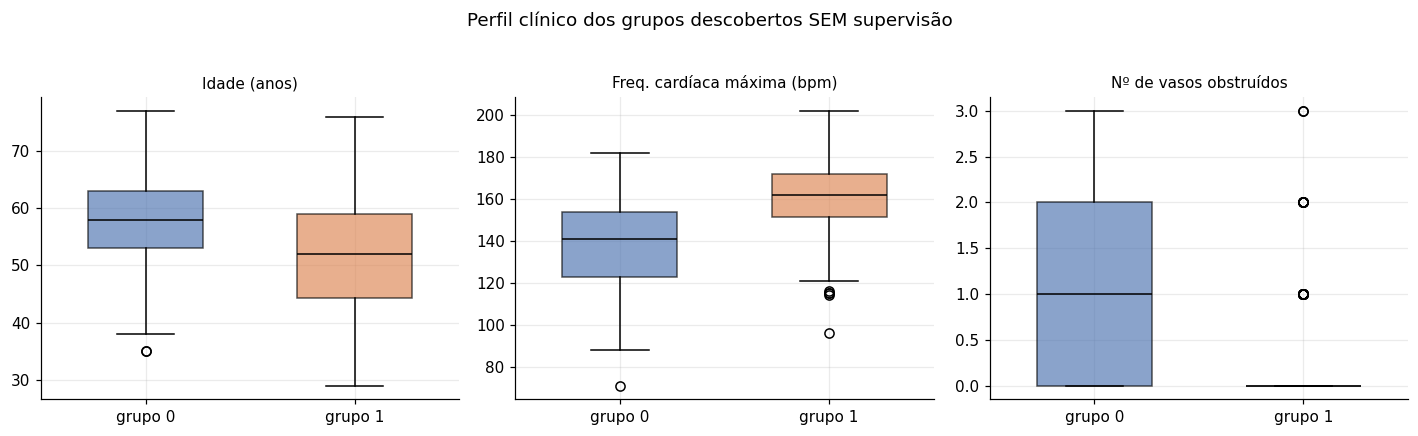

In [23]:
perfil = coracao.assign(grupo=grupos).groupby("grupo")[
    ["idade", "freq_card_max", "n_vasos", "depressao_st", "pressao_repouso", "sexo", "doenca"]
].mean()
perfil.columns = ["idade média", "freq. card. máx.", "nº vasos", "depressão ST",
                  "pressão repouso", "prop. masculino", "prop. doentes"]
print(perfil.round(2).to_string())

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, col, titulo in zip(axes, ["idade", "freq_card_max", "n_vasos"],
                           ["Idade (anos)", "Freq. cardíaca máxima (bpm)", "Nº de vasos obstruídos"]):
    dados = [coracao.loc[grupos == g, col].dropna() for g in (0, 1)]
    bp = ax.boxplot(dados, patch_artist=True, widths=0.55)
    ax.set_xticks([1, 2], ["grupo 0", "grupo 1"])
    for patch, cor in zip(bp["boxes"], [CORES[0], CORES[1]]):
        patch.set_facecolor(cor); patch.set_alpha(0.65)
    for med in bp["medians"]:
        med.set_color("black")
    ax.set_title(titulo, fontsize=10)
fig.suptitle("Perfil clínico dos grupos descobertos SEM supervisão", y=1.03)
plt.tight_layout()
plt.show()

### 🎯 Conclusão do Exercício 7

**(b) e (c)** Os dois grupos têm perfis clinicamente coerentes: um deles concentra
pacientes **mais velhos, com frequência cardíaca máxima menor, mais vasos obstruídos e
maior depressão do segmento ST** — exatamente o perfil de risco cardiovascular. O
K-Means não sabia nada disso; ele apenas encontrou dois aglomerados no espaço de
atributos, e esses aglomerados **correspondem** à distinção clínica.

É esse fenômeno que torna o aprendizado não supervisionado valioso: em domínios onde
rotular custa caro (ou onde nem sabemos ainda quais são as categorias certas), ele
revela estrutura que **já estava lá**. Foi assim que subtipos de câncer e perfis de
consumidores foram descobertos.

**(d) Por que não calcular acurácia diretamente?**

Porque **os rótulos dos grupos são arbitrários**. O K-Means poderia igualmente ter
chamado de "grupo 0" o que chamou de "grupo 1" — a partição seria idêntica e a
acurácia saltaria de 80% para 20%. Uma métrica que muda de valor quando você renomeia
as categorias não está medindo a qualidade do agrupamento.

Por isso usamos medidas **invariantes a permutação de rótulos**, como o **Índice de
Rand Ajustado** (que conta pares de pontos que ficaram juntos ou separados nas duas
partições, e é corrigido para o acaso).

> E um alerta final: só pudemos calcular o ARI porque **tínhamos** os rótulos guardados
> para conferir. Num problema genuinamente não supervisionado, eles não existem — e
> avaliar a qualidade do agrupamento passa a depender de medidas internas (silhueta,
> inércia) e, principalmente, do **julgamento de um especialista do domínio**.

---
## Onde continuamos

Os exercícios levantaram três questões que a próxima aula responde:

- **Como** a árvore decide onde cortar? (entropia, ganho de informação, índice Gini)
- **Por que** o KNN sem padronização vai tão mal, e como escolher o $k$?
- Como comparar dois modelos com **rigor estatístico**, e não no olhômetro?